# RQ1 — resultados: federado × centralizado

> **Qual o tradeoff, em acurácia, comunicação e privacidade, de treinar um modelo
> de HAR de forma federada cross-device em vez de centralizada?**

Notebook **somente de leitura**: lê `results/rqs/`, não treina nada.

| | |
|---|---|
| **I** | treino federado cross-device (clientes = usuários reais) |
| **C** | treino centralizado sobre exatamente as mesmas janelas — *teto de referência* |
| **O** | `test_acc` / F1-macro por regime de rótulo, e MB transmitidos |

## Como ler qualquer número daqui

O centralizado guarda uma linha por célula; o federado, **uma por rodada**. A regra
é a **rodada escolhida pela validação** (maior `val_acc`), reportando o `test_acc`
dela — D4. O teste nunca entra na escolha.

**Três assimetrias entre os braços, todas declaradas no desenho.** Elas empurram o
Δ para cima (a favor do federado), então o Δ observado é um **limite inferior do
custo de federar**:

1. **Orçamento de otimização** (§7) — os braços não fazem o mesmo número de passos
   de gradiente, e a razão **troca de sinal ao longo da curva**: ~7,5× pró-federado
   no `k=1`, 0,74× pró-centralizado no `Full`.
2. **Tuning de LR** (§7.1) — só o federado teve LR buscada (por encoder × federação
   × regime). O centralizado usa `1e-4` herdado da Tabela 12 do benchmark, nunca
   revalidado aqui — e na busca federada esse valor é a **pior** das 4 LRs originais
   em 11–12 das 20 células.
3. **Seleção de modelo** — o federado toma o **máximo de `val_acc` sobre 150
   rodadas**; o centralizado usa early stopping com paciência 50. Mais tentativas de
   seleção = mais otimismo.

## 1. Setup e dados

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
PROJECT_ROOT = None
while _p != _p.parent:
    if (_p / "minerva").is_dir() and (_p / "scripts").is_dir():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")

for p in (PROJECT_ROOT, PROJECT_ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rqs.config import (ENCODERS, FEDERACOES, FULL_SHOTS, K_LEVELS, RESULTS,
                        R_FT, SEEDS_RQ)

In [2]:
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Slots 1-2 do skill `dataviz`. Duas séries — os dois BRAÇOS —, cor constante em
# toda a página, inclusive no Δ (lá o sinal diz quem vence, a cor diz quem é).
C_CENTR, C_FED = "#2a78d6", "#eb6834"
TINTA_1, TINTA_2, TINTA_3 = "#0b0b0b", "#52514e", "#8a8880"
GRADE = "#e6e5e1"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": TINTA_3, "axes.linewidth": 0.8,
    "axes.labelcolor": TINTA_2, "text.color": TINTA_1,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
})

DATASETS = sorted(FEDERACOES)
KS = [str(k) for k in K_LEVELS]
ROTULO_K = {"1": "k=1", "2": "k=2", "4": "k=4", str(FULL_SHOTS): "Full"}

In [3]:
def carrega_federado() -> pd.DataFrame:
    fs = sorted(glob.glob(str(RESULTS / "rq1_federado_parts" / "*.csv")))
    if not fs:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    df = df.dropna(subset=["test_f1_macro", "val_acc"])
    # só células com as R=150 rodadas: parcial a meio caminho enviesa (a rodada
    # boa pode ainda não ter acontecido)
    cont = df.groupby(["encoder", "target", "n_shots", "seed"]).round.count()
    df = (df.set_index(["encoder", "target", "n_shots", "seed"])
            .loc[cont[cont >= R_FT].index].reset_index())
    sel = df.loc[df.groupby(["encoder", "target", "n_shots", "seed"]).val_acc.idxmax()]
    return (sel.rename(columns={"target": "dataset", "n_shots": "k"})
               [["encoder", "dataset", "k", "seed", "test_acc", "test_f1_macro",
                 "round", "lr", "uplink_mb", "downlink_mb"]])


fed = carrega_federado()
cen_p = RESULTS / "rq1_centralizado.csv"
cen = pd.read_csv(cen_p) if cen_p.exists() else pd.DataFrame()
for d in (fed, cen):
    if len(d):
        d["k"] = d["k"].astype(str)

TOTAL = len(ENCODERS) * len(DATASETS) * len(K_LEVELS) * len(SEEDS_RQ)
if len(fed) and len(cen):
    par = cen[["encoder", "dataset", "k", "seed", "test_acc", "test_f1_macro"]].merge(
        fed, on=["encoder", "dataset", "k", "seed"], suffixes=("_centr", "_fed"))
    par["delta"] = (par.test_acc_fed - par.test_acc_centr) * 100
else:
    par = pd.DataFrame()

# Cobertura: proveniência do número, não acompanhamento de fila. Sem isso não dá
# para saber se uma média vem de 4 células ou de 60.
print(f"pares (os dois braços prontos): {len(par)}/{TOTAL}"
      f"  ({len(par)/TOTAL*100:.0f}% da grade)")
if len(par):
    falta_enc = sorted(set(ENCODERS) - set(par.encoder.unique()))
    if falta_enc:
        print(f"[AVISO] encoders ainda ausentes dos pares: {falta_enc}")
    print(par.groupby(["k"]).size().rename("pares").to_frame().T.to_string())

pares (os dois braços prontos): 240/240  (100% da grade)
k       1   2   4  full
pares  60  60  60    60


## 2. Acurácia ao longo do orçamento de rótulo

`k` é rótulo por classe **por cliente**; o centralizado pareado vê `k × n_clientes`
(§3 do desenho). Por isso o eixo é `k`, e não a contagem absoluta, que difere entre
federações.

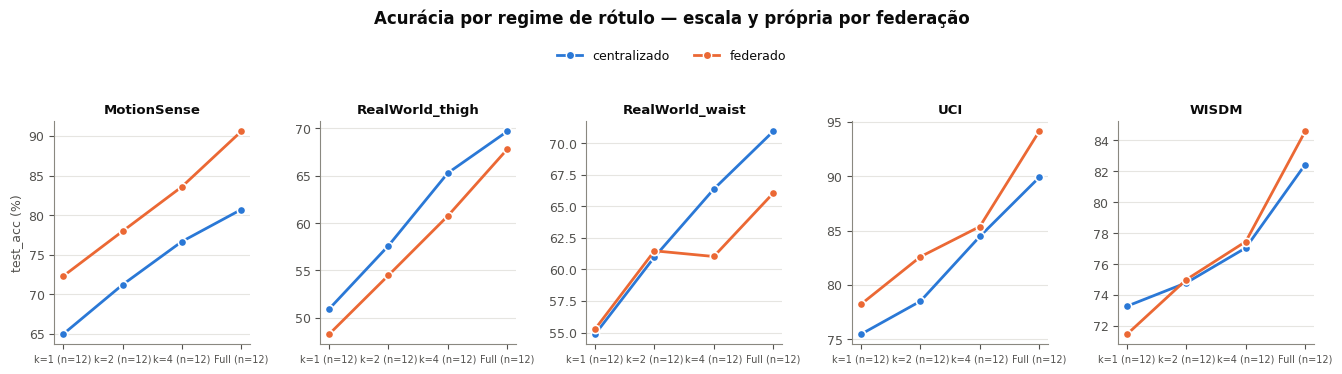

In [4]:
if len(par):
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(2.7 * len(DATASETS), 3.2),
                             squeeze=False)
    for j, d in enumerate(DATASETS):
        ax = axes[0][j]
        ax.set_axisbelow(True); ax.grid(True, axis="y", linewidth=0.8)
        for lado in ("top", "right"):
            ax.spines[lado].set_visible(False)
        sub = par[par.dataset == d]
        x = np.arange(len(KS))
        for col, cor, nome in [("test_acc_centr", C_CENTR, "centralizado"),
                               ("test_acc_fed", C_FED, "federado")]:
            m = [sub[sub.k == k][col].mean() * 100 if len(sub[sub.k == k]) else np.nan
                 for k in KS]
            ax.plot(x, m, color=cor, linewidth=2, marker="o", markersize=6,
                    markeredgecolor="white", markeredgewidth=1.2, label=nome, zorder=3)
        ax.set_xticks(x, [f"{ROTULO_K[k]} (n={len(sub[sub.k == k])})" for k in KS],
                      fontsize=7)
        ax.set_title(d, fontsize=9.5, fontweight="bold", color=TINTA_1)
        if j == 0:
            ax.set_ylabel("test_acc (%)")
    maos = [plt.Line2D([], [], color=c, linewidth=2, marker="o", markersize=6,
                       markeredgecolor="white", label=n)
            for c, n in [(C_CENTR, "centralizado"), (C_FED, "federado")]]
    fig.legend(handles=maos, loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2)
    fig.suptitle("Acurácia por regime de rótulo — escala y própria por federação",
                 fontsize=12, fontweight="bold", color=TINTA_1, y=1.15)
    fig.tight_layout()
    plt.show()

## 3. O Δ

`Δ = federado − centralizado`, em pontos percentuais. **Positivo = o federado ganha.**
Laranja onde o federado vence, azul onde o centralizado vence — mesma cor da seção
anterior.

A nuvem à direita existe porque a média esconde inversão de sinal: um Δ médio de
+1 pp pode ser "todo mundo empata" ou "metade ganha 8 e metade perde 6".

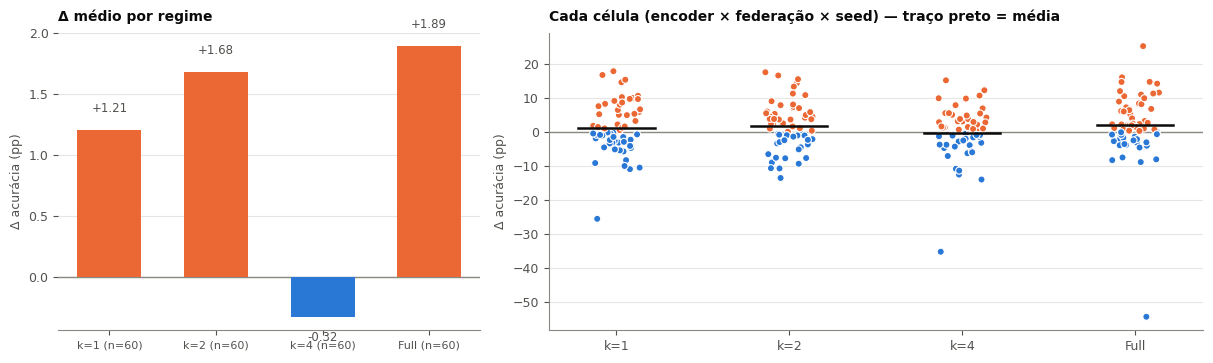

       n  Δ médio     dp  mediana
k                                
1     60     1.21   7.61     0.03
2     60     1.68   6.97     1.90
4     60    -0.32   7.37     0.51
full  60     1.89  10.02     1.62


In [5]:
if len(par):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 3.7),
                             gridspec_kw={"width_ratios": [1, 1.55]})

    ax = axes[0]
    ax.set_axisbelow(True); ax.grid(True, axis="y", linewidth=0.8)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    med = [par[par.k == k].delta.mean() if len(par[par.k == k]) else np.nan for k in KS]
    ns = [len(par[par.k == k]) for k in KS]
    ax.bar(range(len(KS)), med, width=0.6, zorder=3,
           color=[C_FED if (m == m and m >= 0) else C_CENTR for m in med])
    ax.axhline(0, color=TINTA_3, linewidth=1)
    for i, m in enumerate(med):
        if m == m:
            ax.text(i, m + (0.12 if m >= 0 else -0.12), f"{m:+.2f}", ha="center",
                    va="bottom" if m >= 0 else "top", fontsize=8.5, color=TINTA_2)
    ax.set_xticks(range(len(KS)),
                  [f"{ROTULO_K[k]} (n={n})" for k, n in zip(KS, ns)], fontsize=8)
    ax.set_ylabel("Δ acurácia (pp)")
    ax.set_title("Δ médio por regime", fontsize=10, fontweight="bold",
                 color=TINTA_1, loc="left", pad=8)

    ax = axes[1]
    ax.set_axisbelow(True); ax.grid(True, axis="y", linewidth=0.8)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    rs = np.random.RandomState(0)
    for i, k in enumerate(KS):
        v = par[par.k == k].delta.values
        if not len(v):
            continue
        ax.scatter(np.full(len(v), i) + (rs.rand(len(v)) - 0.5) * 0.28, v, s=26,
                   c=[C_FED if x >= 0 else C_CENTR for x in v],
                   edgecolors="white", linewidths=0.8, zorder=3)
        ax.plot([i - 0.22, i + 0.22], [v.mean()] * 2, color=TINTA_1,
                linewidth=1.8, zorder=4)
    ax.axhline(0, color=TINTA_3, linewidth=1)
    ax.set_xticks(range(len(KS)), [ROTULO_K[k] for k in KS])
    ax.set_ylabel("Δ acurácia (pp)")
    ax.set_title("Cada célula (encoder × federação × seed) — traço preto = média",
                 fontsize=10, fontweight="bold", color=TINTA_1, loc="left", pad=8)

    fig.tight_layout()
    plt.show()

    print((par.groupby("k").delta.agg(["count", "mean", "std", "median"])
              .reindex(KS).round(2)
              .rename(columns={"count": "n", "mean": "Δ médio", "std": "dp",
                               "median": "mediana"})).to_string())

## 4. A célula `Full` — a mais importante da RQ1

No `Full` os dois braços veem **o mesmo corpus e os mesmos usuários**: o Δ ali é o
efeito de federar sobre exatamente as mesmas janelas, sem diferença de dado. É
também onde o orçamento de otimização favorece o **centralizado** (0,74×), então um
Δ positivo aqui **não** se explica pela assimetria §7 — sobram a LR (§7.1) e a
seleção.

In [6]:
if len(par):
    f = par[par.k == str(FULL_SHOTS)]
    if len(f):
        print(f"n={len(f)} de {len(ENCODERS)*len(DATASETS)*len(SEEDS_RQ)} células Full")
        print(f"Δ médio {f.delta.mean():+.2f} pp | mediana {f.delta.median():+.2f} | "
              f"dp {f.delta.std():.2f} | federado vence em {(f.delta>0).sum()}/{len(f)}")
        print()
        print(f.groupby("encoder").delta.agg(["count", "mean", "std"]).round(2).to_string())
        print()
        print(f.groupby("dataset").delta.agg(["count", "mean"]).round(2).to_string())
    else:
        print("nenhuma célula Full pareada ainda.")

n=60 de 60 células Full
Δ médio +1.89 pp | mediana +1.62 | dp 10.02 | federado vence em 37/60

           count  mean    std
encoder                      
cnnpff        15 -3.11  15.72
resnetse5     15  1.38   5.04
rnn           15  8.55   6.79
tstcc         15  0.75   5.35

                 count  mean
dataset                     
MotionSense         12  9.87
RealWorld_thigh     12 -1.89
RealWorld_waist     12 -4.89
UCI                 12  4.23
WISDM               12  2.14


### 4.1 Barras `Full`: cada encoder e a média

Mesma célula da seção anterior, em nível: **acurácia absoluta**, não Δ. Um painel
por federação com os 4 encoders lado a lado, e o último painel com a **média dos 4**
por federação.

Barra de erro: dp entre as 3 seeds nos painéis por encoder; nos da média, dp **entre
os 4 encoders** — é a dispersão do que aquele painel agrega, não ruído de repetição.

A leitura que a média esconde: o sinal do Δ **muda de encoder para encoder dentro da
mesma federação** (ver `cnnpff` em `RealWorld_waist` contra os outros três lá), então
"o federado ganha em X" só vale por par encoder × federação.

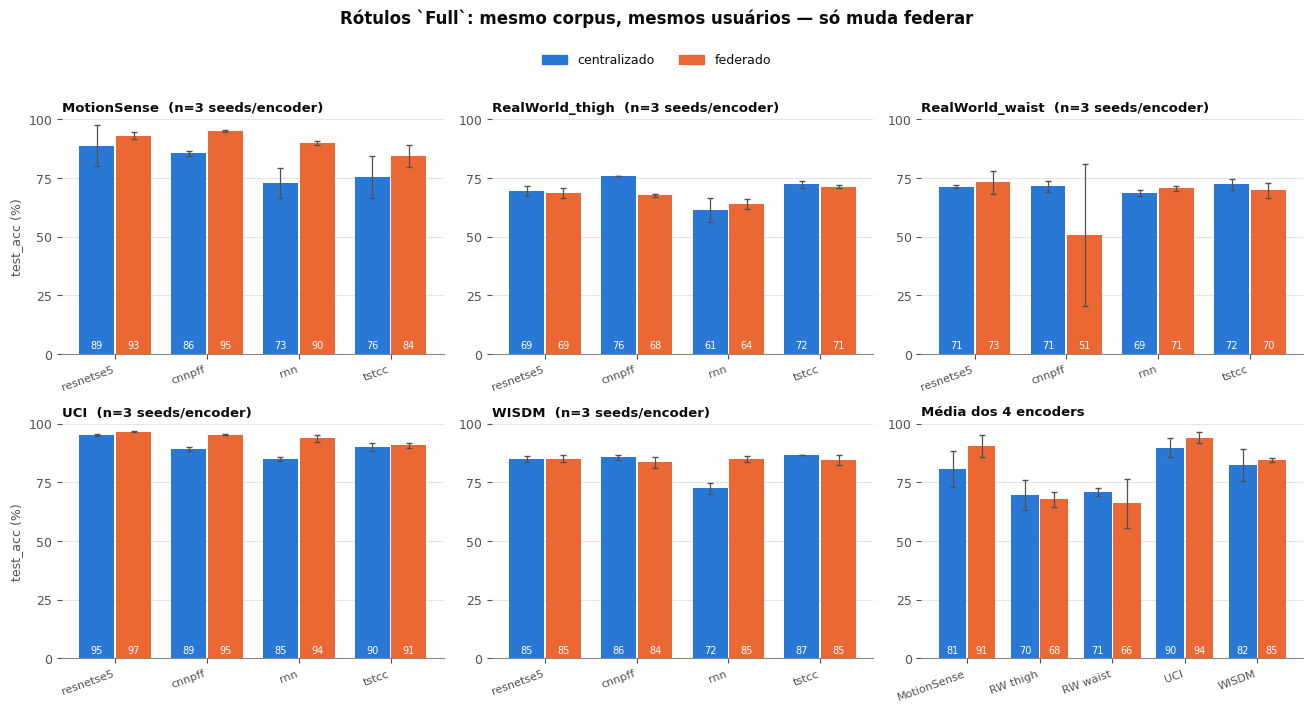

test_acc no regime Full (média das seeds) — Δ = fed − centr, em pp
                           n  centr    fed  delta_pp
dataset         encoder                             
MotionSense     cnnpff     3  0.855  0.949     9.375
                resnetse5  3  0.888  0.930     4.264
                rnn        3  0.729  0.900    17.122
                tstcc      3  0.756  0.843     8.724
RealWorld_thigh cnnpff     3  0.758  0.676    -8.206
                resnetse5  3  0.694  0.685    -0.903
                rnn        3  0.612  0.638     2.593
                tstcc      3  0.723  0.712    -1.053
RealWorld_waist cnnpff     3  0.714  0.506   -20.768
                resnetse5  3  0.714  0.732     1.849
                rnn        3  0.686  0.706     1.992
                tstcc      3  0.723  0.697    -2.630
UCI             cnnpff     3  0.891  0.953     6.146
                resnetse5  3  0.952  0.966     1.406
                rnn        3  0.851  0.938     8.698
                tstcc      3  0.

In [7]:
if len(par):
    f = par[par.k == str(FULL_SHOTS)]

if len(par) and len(f):
    # dp entre as seeds: a barra é a média das SEEDS_RQ, e a barra de erro diz
    # se a diferença entre os dois braços é maior que a repetição.
    cel = (f.groupby(["dataset", "encoder"])
             .agg(c=("test_acc_centr", "mean"), c_dp=("test_acc_centr", "std"),
                  fd=("test_acc_fed", "mean"), f_dp=("test_acc_fed", "std"),
                  n=("test_acc_fed", "size")))
    # No painel da media a barra de erro e o dp ENTRE OS 4 ENCODERS (media de
    # cada um), nao entre as 12 celulas: e a dispersao do que o painel agrega.
    med = cel.groupby("dataset").agg(c=("c", "mean"), c_dp=("c", "std"),
                                     fd=("fd", "mean"), f_dp=("fd", "std"),
                                     n=("n", "sum"))

    L = 0.38                       # largura da barra; 2 barras + folga = 0,84
    def painel(ax, cats, mc, mdc, mf, mdf, titulo, rot=0):
        ax.set_axisbelow(True); ax.grid(True, axis="y", linewidth=0.8)
        for lado in ("top", "right", "left"):
            ax.spines[lado].set_visible(False)
        x = np.arange(len(cats))
        for off, m, dp, cor, nome in [(-L / 2 - 0.01, mc, mdc, C_CENTR, "centralizado"),
                                      (+L / 2 + 0.01, mf, mdf, C_FED, "federado")]:
            ax.bar(x + off, np.array(m) * 100, width=L, color=cor, zorder=3, label=nome)
            ax.errorbar(x + off, np.array(m) * 100, yerr=np.array(dp) * 100, fmt="none",
                        ecolor=TINTA_2, elinewidth=0.9, capsize=2.5, zorder=4)
            for xi, v in zip(x + off, np.array(m) * 100):
                ax.text(xi, 1.5, f"{v:.0f}", ha="center", va="bottom", fontsize=7,
                        color="white", zorder=5)
        ax.set_xticks(x, cats, fontsize=8, rotation=rot,
                      ha="right" if rot else "center")
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_title(titulo, fontsize=9.5, fontweight="bold", color=TINTA_1, loc="left")

    fig, axes = plt.subplots(2, 3, figsize=(13.2, 6.6))
    for j, d in enumerate(DATASETS):
        ax = axes[j // 3][j % 3]
        sub = cel.loc[d].reindex(ENCODERS)
        painel(ax, list(sub.index), sub.c, sub.c_dp, sub.fd, sub.f_dp,
               f"{d}  (n={int(sub.n.iloc[0])} seeds/encoder)", rot=20)
        if j % 3 == 0:
            ax.set_ylabel("test_acc (%)")

    ax = axes[1][2]
    m = med.reindex(DATASETS)
    painel(ax, [d.replace("RealWorld_", "RW ") for d in m.index],
           m.c, m.c_dp, m.fd, m.f_dp, "Média dos 4 encoders", rot=20)

    maos = [plt.Rectangle((0, 0), 1, 1, color=c, label=n)
            for c, n in [(C_CENTR, "centralizado"), (C_FED, "federado")]]
    fig.legend(handles=maos, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2)
    fig.suptitle("Rótulos `Full`: mesmo corpus, mesmos usuários — só muda federar",
                 fontsize=12, fontweight="bold", color=TINTA_1, y=1.07)
    fig.tight_layout()
    plt.show()

    t = cel.copy()
    t["delta_pp"] = (t.fd - t.c) * 100
    t = t[["n", "c", "fd", "delta_pp"]].rename(
        columns={"c": "centr", "fd": "fed"})
    print("test_acc no regime Full (média das seeds) — Δ = fed − centr, em pp")
    print(t.round(3).to_string())
    print()
    tm = med.copy()
    tm["delta_pp"] = (tm.fd - tm.c) * 100
    print("Média sobre os encoders:")
    print(tm[["n", "c", "fd", "delta_pp"]].rename(
        columns={"c": "centr", "fd": "fed"}).round(3).to_string())

## 5. ⚠️ Quanto do Δ é otimismo de seleção

Os dois braços escolhem o modelo reportado de maneiras diferentes:

| braço | como escolhe |
|---|---|
| centralizado | early stopping, **paciência 50** em `val_loss`, ≤100 épocas — protocolo do benchmark (da Luz et al. §V, verificado no PDF em 2026-08-24) |
| federado | **argmax de `val_acc` sobre 150 rodadas** — regra nossa (D4), sem contrapartida no benchmark |

São **duas** diferenças: a métrica (`val_loss` × `val_acc` — selecionar na mesma
família do que se reporta é mais otimista) e o lookahead (paciência limitada ×
varredura completa).

A célula abaixo emula a **disciplina** do early stopping sobre o cache federado,
varrendo paciências. `pac=150` é o argmax global, isto é, a regra atual.

> **Só corrige o lookahead, não a métrica.** `val_loss` não existia no cache
> federado até 24/08 (`run_cross_device._eval_val` devolvia só acc/F1); a partir
> dali o runner grava, mas os parciais antigos não têm. Então **o custo real de
> federar é mais negativo do que a coluna `pac=50`**.

Δ = federado − centralizado (pp), por paciência do early stopping emulado
(pac=150 = argmax global = regra atual, D4)

       n    10    25    50    75   150
k                                     
1     60 -0.39  0.52  0.76  0.92  1.21
2     60 -0.78  0.64  1.21  1.48  1.68
4     60 -2.84 -1.52 -0.92 -0.89 -0.32
full  60 -3.32 -0.24  0.82  1.35  1.89


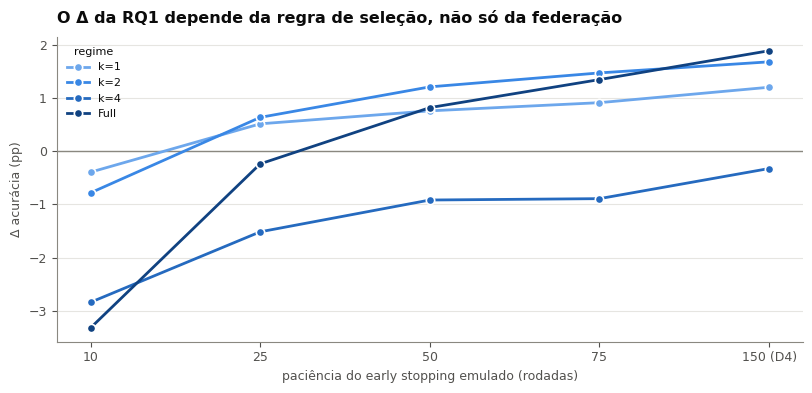

In [8]:
from analysis.rq1_selecao import carrega_federado, escolhe_com_paciencia

bruto = carrega_federado()
PACIENCIAS = [10, 25, 50, 75, R_FT]

if len(bruto) and len(cen):
    col = {}
    for pac in PACIENCIAS:
        esc = []
        for chave, g in bruto.groupby(["encoder", "target", "n_shots", "seed"], sort=False):
            t, _ = escolhe_com_paciencia(g, pac)
            esc.append((*chave, t))
        e = pd.DataFrame(esc, columns=["encoder", "dataset", "k", "seed", "test_acc"])
        e["k"] = e["k"].astype(str)
        m = cen[["encoder", "dataset", "k", "seed", "test_acc"]].merge(
            e, on=["encoder", "dataset", "k", "seed"], suffixes=("_c", "_f"))
        m["d"] = (m.test_acc_f - m.test_acc_c) * 100
        col[pac] = m.groupby("k").d.mean().reindex(KS)
        n_pac = m.groupby("k").size().reindex(KS)

    tab = pd.DataFrame(col)
    tab.insert(0, "n", n_pac)
    print("Δ = federado − centralizado (pp), por paciência do early stopping emulado")
    print(f"(pac={R_FT} = argmax global = regra atual, D4)")
    print()
    print(tab.round(2).to_string())

    fig, ax = plt.subplots(figsize=(8.2, 4.0))
    ax.set_axisbelow(True); ax.grid(True, axis="y", linewidth=0.8)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    # uma linha por regime: a pergunta e como o Δ ANDA com a regra de selecao
    # rampa sequencial de 1 tom, degraus 300/400/500/650 -- os degraus mais claros
    # (100/250) nao alcancam contraste sobre o branco (regra do relevo, palette.md)
    tons = ["#6da7ec", "#3987e5", "#256abf", "#104281"]
    for i, k in enumerate(KS):
        ax.plot(range(len(PACIENCIAS)), [col[p][k] for p in PACIENCIAS],
                color=tons[i], linewidth=2, marker="o", markersize=6,
                markeredgecolor="white", markeredgewidth=1.2,
                label=ROTULO_K[k], zorder=3)
    ax.axhline(0, color=TINTA_3, linewidth=1)
    ax.set_xticks(range(len(PACIENCIAS)),
                  [f"{p}" if p != R_FT else f"{p} (D4)" for p in PACIENCIAS])
    ax.set_xlabel("paciência do early stopping emulado (rodadas)")
    ax.set_ylabel("Δ acurácia (pp)")
    ax.legend(title="regime", fontsize=8, title_fontsize=8)
    ax.set_title("O Δ da RQ1 depende da regra de seleção, não só da federação",
                 fontsize=11.5, fontweight="bold", color=TINTA_1, loc="left", pad=10)
    fig.tight_layout()
    plt.show()

## 6. Comunicação

O eixo (b) da RQ1: quantos MB o braço federado transmite para chegar ao número que
reporta. O centralizado transmite zero — o dado já está reunido, que é justamente o
que se abre mão.

In [9]:
if len(fed):
    com = fed.copy()
    com["total_mb"] = com.uplink_mb + com.downlink_mb
    t = (com.groupby("k").agg(n=("total_mb", "size"),
                              mb_ate_a_rodada=("total_mb", "mean"),
                              rodada=("round", "mean")).reindex(KS).round(1))
    print("MB acumulados até a rodada escolhida pela validação:")
    print(t.to_string())
    print()
    print("Leitura: o federado paga esses MB para igualar (ou superar) um braço que")
    print("não transmite nada. O custo de comunicação é o tradeoff real e medido —")
    print("o de acurácia, nesta grade, está confundido pelas assimetrias do topo.")

MB acumulados até a rodada escolhida pela validação:
       n  mb_ate_a_rodada  rodada
k                                
1     60            135.7    73.0
2     60            135.7    86.1
4     60            135.7    89.6
full  60            135.7    79.6

Leitura: o federado paga esses MB para igualar (ou superar) um braço que
não transmite nada. O custo de comunicação é o tradeoff real e medido —
o de acurácia, nesta grade, está confundido pelas assimetrias do topo.
